[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ThorKlm/PLI-Parallax/blob/main/notebooks/pli_parallax_usage_examples.ipynb)

# PLI-Parallax: usage example notebook

Multi-teacher protein-ligand distance and contact labels with a three-bead
coordinate store.

The deposit holds 3D coordinates for 48,985 protein-ligand systems together with
the residue-to-ligand-atom distance tables derived from them. The teacher axis is
fixed and ordered: the experimental pose where one exists, Chai-1 and Boltz-2
folding the complex from sequence, a second Boltz-2 pass conditioned on a
multiple-sequence alignment, and smina docking into a rigid receptor. Two tiers
run in parallel. The crystal tier takes BioLiP2 complexes where the protein and
ligand were solved together, so a predicted pose can be measured directly against
the deposited one. The corpus tier pairs BindingDB ligands with AlphaFold
receptors across 31,746 systems, extending the resource well beyond what
experimental structures cover, with a calibrated per-system reliability estimate
supplied alongside.

The coordinate store is the primary artifact and the distance tables are a
materialised view of it at a fixed 15 A cutoff. Every residue carries three
points: the alpha carbon, the centroid of its side-chain heavy atoms and the
backbone carbonyl carbon. Each is a separate array of length `n_res`, aligned by
position with `res_types`, so a one-, two- or three-bead representation is a
selection rather than a conversion, and the residue-residue and ligand-ligand
maps the tables do not carry are available directly from the coordinates.

This notebook fetches the deposit, verifies it against `MANIFEST.sha256`, reports
the quantities that decide whether it fits a given problem, recomputes a distance
table from the store, and draws the bead representation across teachers. It
closes on the one property worth knowing before training on the tables: a contact
row exists only where the minimum heavy-atom distance is at most 15 A, so a
system carries rows for 23.5 percent of its residues and the absence of a row
means beyond the cutoff rather than a measured non-contact.

In [1]:
# The deposit was written with pyarrow 25.0.1, h5py 3.16.0, pandas 3.0.5 and
# numpy 1.26.4 on Python 3.12.
import numpy as np, pandas as pd, h5py, matplotlib
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.compute as pc
import matplotlib.pyplot as plt
for m in (np, pd, h5py, pa, matplotlib):
    print(f"{m.__name__:12s} {m.__version__}")

# only needed while the repo is private:
# from huggingface_hub import notebook_login
# notebook_login()

numpy        2.1.3
pandas       2.2.3
h5py         3.16.0
pyarrow      25.0.1
matplotlib   3.10.0


In [2]:
# cell 1 -- fetch and verify
import os, hashlib, shutil

# --- Hugging Face -----------------------------------------------------------
from huggingface_hub import snapshot_download

D = snapshot_download(repo_id="ThorKl/PLI-parallax", repo_type="dataset")
D = os.path.join(D, "deposit")   # the deposit sits under deposit/; the root README is the card
# Tables only, skipping the 5 GB of coordinate stores.
# D = snapshot_download(repo_id="ThorKl/PLI-parallax", repo_type="dataset",
#                       allow_patterns=["labels/*","metadata/*","splits/*",
#                                       "*.md","*.json","*.sha256","*.csv"])

# --- Zenodo -----------------------------------------------------------------
# uncomment this block and comment out the two lines above to pull the
# archived content from Zenodo instead

# Zenodo strips directory components from uploaded filenames, so the files
# arrive flat and the tree is rebuilt from the paths in MANIFEST.sha256.
# !pip -q install "zenodo-get>=2.0"
# import subprocess
# ZENODO_DOI = "10.5281/zenodo.21560088"
# D = "deposit_v3"
# os.makedirs(D, exist_ok=True)
# subprocess.run(["zenodo_get", "-d", ZENODO_DOI, "-o", D], check=True)
# for line in open(f"{D}/MANIFEST.sha256"):
#     if not line.strip():
#         continue
#     rel = line.strip().split("  ", 1)[1]
#     if "/" not in rel or os.path.exists(f"{D}/{rel}"):
#         continue
#     flat = f"{D}/{os.path.basename(rel)}"
#     if os.path.exists(flat):
#         os.makedirs(os.path.dirname(f"{D}/{rel}"), exist_ok=True)
#         shutil.move(flat, f"{D}/{rel}")


def sha256(p, chunk=1 << 22):
    h = hashlib.sha256()
    with open(p, "rb") as fh:
        for b in iter(lambda: fh.read(chunk), b""): h.update(b)
    return h.hexdigest()

bad = [rel for want, rel in
       (l.strip().split("  ", 1) for l in open(f"{D}/MANIFEST.sha256") if l.strip())
       if not os.path.exists(f"{D}/{rel}") or sha256(f"{D}/{rel}") != want]
print(D)
print(sum(len(f) for _, _, f in os.walk(D)), "files,", len(bad), "failing:", bad or "none")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 46 files:   0%|          | 0/46 [00:00<?, ?it/s]

/root/.cache/huggingface/hub/datasets--ThorKl--PLI-parallax/snapshots/87ba48e0c8bdbf6e659ca9d2865fa917085e62b2
46 files, 0 failing: none


In [3]:
SLOT = {"crystal": 0, "chai1": 1, "boltz2": 2, "boltz2_msa": 3, "smina": 4}
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [4]:
# cell 2 -- the numbers needed before deciding whether this fits your problem.
# Grouped by the question each answers rather than by which file they came from.

print("=" * 75)
print("LABEL SETS")
print("=" * 75)

sets = []
for f in sorted(os.listdir(f"{D}/labels")):
    if not f.endswith("_meta.parquet"): continue
    stem = f[len("labels_"):-len("_meta.parquet")]
    mf = pq.ParquetFile(f"{D}/labels/{f}")
    cf = pq.ParquetFile(f"{D}/labels/labels_{stem}_contacts.parquet")
    sets.append({"set": stem, "systems": mf.metadata.num_rows,
                 "pairs": cf.metadata.num_rows,
                 "pairs_per_system": cf.metadata.num_rows / mf.metadata.num_rows,
                 "MB": os.path.getsize(f"{D}/labels/labels_{stem}_contacts.parquet") / 2**20})
sets = pd.DataFrame(sets).sort_values("pairs", ascending=False)
print(sets.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))
print(f"\ntotal {sets.pairs.sum():,} labelled pairs over {sets.systems.sum():,} set-system rows")

print("")
print("=" * 75)
print("HOW THE TIERS OVERLAP  (which systems can you train on, and with what)")
print("=" * 75)
S = {a: set(pq.read_table(f"{D}/labels/labels_{a}_meta.parquet",
                          columns=["system_id"]).column(0).to_pylist())
     for a in sets["set"]}
cor = ["smina_corpus", "chai1_corpus", "boltz2_corpus", "boltz2_msa_corpus"]
xtl = ["smina_crystal", "chai1_crystal", "boltz2_crystal", "boltz2_msa_crystal"]
print(f"corpus union                 {len(set().union(*[S[a] for a in cor])):>7,}")
print(f"corpus, all three predicted  {len(S[cor[0]] & S[cor[1]] & S[cor[2]]):>7,}")
print(f"crystal ground truth         {len(S['crystal_groundtruth']):>7,}")
print(f"crystal, all three predicted {len(S[xtl[0]] & S[xtl[1]] & S[xtl[2]]):>7,}")
print(f"crystal, three plus truth    {len(S[xtl[0]] & S[xtl[1]] & S[xtl[2]] & S['crystal_groundtruth']):>7,}"
      "   <- the cohort for anything supervised")
print(f"tier id overlap              {len(set().union(*[S[a] for a in cor]) & S['crystal_groundtruth']):>7,}"
      "   (disjoint by construction)")

print("")
print("=" * 75)
print("COORDINATE STORES")
print("=" * 75)

for tag in ("corpus", "crystal"):
    p = f"{D}/stores/{tag}.h5"
    if not os.path.exists(p):
        print(f"{tag}: not downloaded")
        continue
    with h5py.File(p, "r") as fh:
        ids = list(fh)
        a0 = fh[ids[0]].attrs
        sc_ = int(a0["scale"])
        teach = [x.decode() if isinstance(x, bytes) else x for x in a0["teachers"]]
        pres = {}
        for s in ids[:3000]:
            for t in fh[s].get("protein", {}): pres[t] = pres.get(t, 0) + 1
    print(f"{tag:8s} {len(ids):>7,} systems  {os.path.getsize(p)/2**30:5.2f} GiB  "
          f"scale {sc_} (0.01 A)")
    print(f"         teacher axis {teach}")
    print(f"         receptor groups present, first 3000 systems: "
          + ", ".join(f"{k} {v}" for k, v in sorted(pres.items(), key=lambda x: -x[1])))

print("")
print("=" * 75)
print("WHAT A ROW DOES NOT SAY")
print("=" * 75)

mt = pq.read_table(f"{D}/labels/labels_crystal_groundtruth_meta.parquet",
                   columns=["system_id", "n_res"]).to_pandas()
ct = pq.read_table(f"{D}/labels/labels_crystal_groundtruth_contacts.parquet",
                   columns=["system_id", "res_row"])
cov = (ct.group_by("system_id").aggregate([("res_row", "count_distinct")]).to_pandas()
       .set_index("system_id").join(mt.set_index("system_id")))
frac = (cov.res_row_count_distinct / cov.n_res).dropna()
print(f"a system carries rows for {100*frac.mean():.1f} % of its residues "
      f"(p10 {100*frac.quantile(.1):.1f}, p90 {100*frac.quantile(.9):.1f})")
print(f"the other {100*(1-frac.mean()):.1f} % are beyond the 15 A cutoff, NOT measured non-contacts")
print("an outer join that fills 0.0 on the missing pairs is therefore wrong")
nulls = {}
for c in ("affinity", "conf1", "conf2", "n_lig_heavy", "pocket_rank", "n_res"):
    tot = pop = 0
    for f in sorted(os.listdir(f"{D}/labels")):
        if not f.endswith("_meta.parquet"): continue
        s = pq.ParquetFile(f"{D}/labels/{f}").schema_arrow
        if c not in s.names: continue
        col = pq.read_table(f"{D}/labels/{f}", columns=[c]).column(c).combine_chunks()
        tot += len(col)
        pop += len(col) - col.null_count
    nulls[c] = (pop, tot)
print("\npopulated / total across the nine meta tables:")
for k, (a, b) in nulls.items():
    print(f"  {k:<14} {a:>8,} / {b:>8,}   ({100*a/b:5.1f} %)")
print("null and zero are different, fillna(0) on affinity or conf invents measurements")

print("")
print("=" * 75)
print("RELIABILITY  (how many systems survive a filter)")
print("=" * 75)
rel = pd.read_parquet(f"{D}/metadata/system_reliability.parquet")
fl = rel.pred_accuracy.min()
print(rel.groupby("tier").agg(n=("system_id", "size"),
                              agreement=("agreement", "median"),
                              pred_acc=("pred_accuracy", "median")).to_string())
for thr in (0.30, 0.50, 0.70):
    sub = rel[rel.pred_accuracy >= thr]
    print(f"  pred_accuracy >= {thr:.2f}: {len(sub):>6,} total  "
          f"({(sub.tier=='corpus').sum():,} corpus, {(sub.tier=='crystal').sum():,} crystal)")
print(f"  {int((rel.pred_accuracy <= fl+1e-9).sum()):,} systems sit exactly on the isotonic "
      f"fit floor {fl:.4f}, which is the estimator's lower bound, not a measured accuracy")
print(f"  conformal_halfwidth_90 takes {rel.conformal_halfwidth_90.nunique()} distinct value "
      f"({rel.conformal_halfwidth_90.iloc[0]:.4f}): one marginal interval, not per-system")

print("")
print("=" * 75)
print("SPLITS")
print("=" * 75)
for f in sorted(os.listdir(f"{D}/splits")):
    t = pq.ParquetFile(f"{D}/splits/{f}")
    print(f"  {f:<34} {t.metadata.num_rows:>10,} rows  {t.metadata.num_columns:>2} cols")
sc = pd.read_parquet(f"{D}/splits/split_summary_corpus.parquet")
sx = pd.read_parquet(f"{D}/splits/split_summary_crystal.parquet")
print(f"\n{len(sc)} corpus and {len(sx)} crystal configurations")
print("mean ligand C2ST AUC by family (0.5 = folds indistinguishable):")
fam = pd.DataFrame({"corpus": sc.groupby("family").c2st_auc.mean(),
                    "crystal": sx.groupby("family").c2st_auc.mean()})
print(fam.round(3).to_string())
print(f"underpowered (test fold under 5 % of the tier): "
      f"{int((sc.n_test < 0.05*sc.n_systems).sum())} corpus, "
      f"{int((sx.n_test < 0.05*sx.n_systems).sum())} crystal -- check n_test before using a tag")

LABEL SETS
                set  systems    pairs  pairs_per_system    MB
       smina_corpus    31713 70033209           2,208.3 233.6
      boltz2_corpus    23494 67281516           2,863.8 223.9
       chai1_corpus    23485 54348638           2,314.2 181.3
crystal_groundtruth    19350 46881795           2,422.8 159.3
     boltz2_crystal     8725 21637489           2,479.9  72.8
      chai1_crystal     9410 21558787           2,291.1  72.5
      smina_crystal    11543 21317135           1,846.8  71.4
 boltz2_msa_crystal     1755  3890602           2,216.9  13.0
  boltz2_msa_corpus      161   365475           2,270.0   1.2

total 307,314,646 labelled pairs over 129,636 set-system rows

HOW THE TIERS OVERLAP  (which systems can you train on, and with what)
corpus union                  31,746
corpus, all three predicted   23,451
crystal ground truth          19,350
crystal, all three predicted   7,166
crystal, three plus truth      7,166   <- the cohort for anything supervised
tier id o

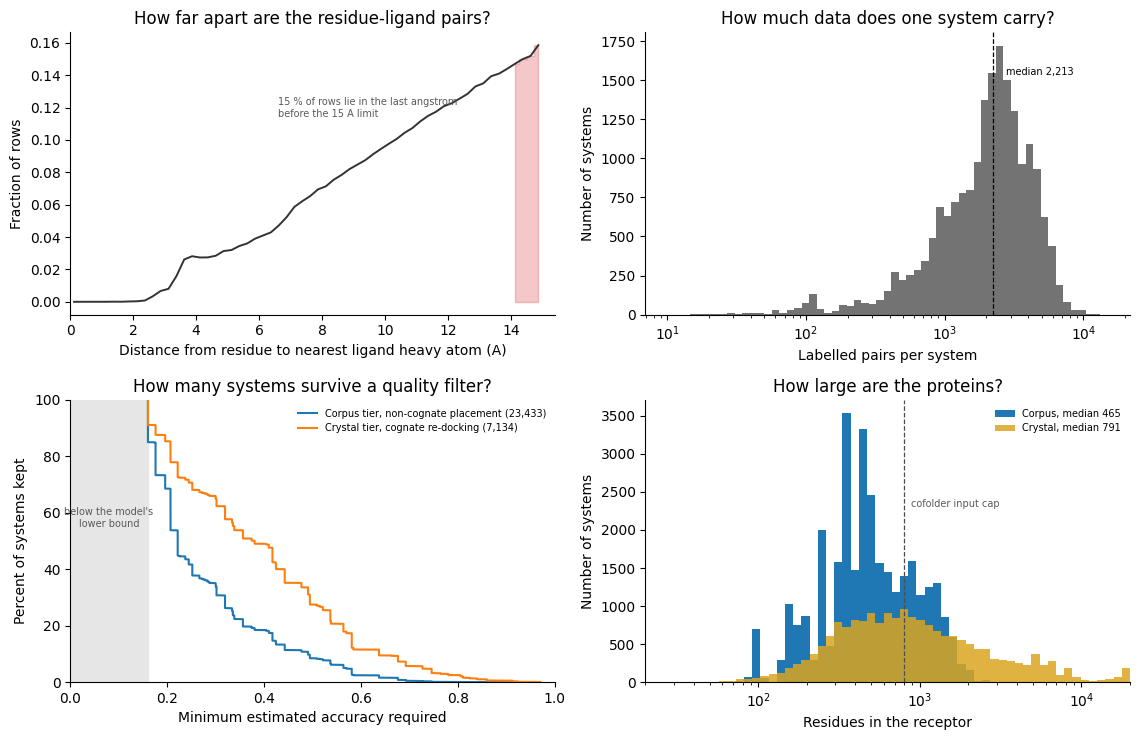

In [5]:
# cell 3
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7.5))

# All four teacher sets are indistinguishable on this axis: the shape comes from
# the geometry of a 15 A shell, not from whether the pose is right. They differ in
# which residues they select, so only the experimental set is drawn.

pf = pq.ParquetFile(f"{D}/labels/labels_crystal_groundtruth_contacts.parquet")
a = np.asarray(pf.read_row_group(0, columns=["d_min"]).column(0))
del pf
bins = np.arange(0, 15.001, 0.25)
h, e = np.histogram(a, bins=bins, density=True)
mid = 0.5 * (e[:-1] + e[1:])
ax[0, 0].plot(mid, h, lw=1.4, color="0.2")
ax[0, 0].fill_between(mid, h, where=mid > 14, color="tab:red", alpha=0.25, step="mid")
ax[0, 0].annotate(f"{100*(a > 14).mean():.0f} % of rows lie in the last angstrom\n"
                  "before the 15 A limit",
                  xy=(14.2, h[-4]), xytext=(6.6, h.max()*0.72), fontsize=7, color="0.35")
ax[0, 0].set(xlabel="Distance from residue to nearest ligand heavy atom (A)",
             ylabel="Fraction of rows", xlim=(0, 15.4),
             title="How far apart are the residue-ligand pairs?")
del a

t = pq.read_table(f"{D}/labels/labels_crystal_groundtruth_contacts.parquet",
                  columns=["system_id"])
n = np.asarray(t.group_by("system_id").aggregate([("system_id","count")])
                .column("system_id_count"))
del t
ax[0, 1].hist(n, bins=np.logspace(1, np.log10(n.max()), 60), color="0.45")
ax[0, 1].axvline(np.median(n), color="k", lw=0.9, ls="--")
ax[0, 1].annotate(f"median {int(np.median(n)):,}", xy=(np.median(n)*1.15, 0),
                  xytext=(np.median(n)*1.25, ax[0,1].get_ylim()[1]*0.85), fontsize=7)
ax[0, 1].set(xscale="log", xlabel="Labelled pairs per system",
             ylabel="Number of systems", title="How much data does one system carry?")

# The two tiers pose different problems. Crystal re-docks a ligand into the
# structure it was solved in
# corpus places a ligand on a predicted receptor with
# no experimental answer. The isotonic fit was made on the crystal tier and applied
# to the corpus unchanged, so this is not a quality comparison.
floor = rel.pred_accuracy.min()
NAME = {"crystal": "Crystal tier, cognate re-docking",
        "corpus": "Corpus tier, non-cognate placement"}
for tier, g_ in rel.groupby("tier"):
    v = np.sort(g_.pred_accuracy.values)
    ax[1, 0].plot(v, 100*np.arange(len(v), 0, -1)/len(v), lw=1.5,
                  label=f"{NAME[tier]} ({len(v):,})")
ax[1, 0].axvspan(0, floor, color="0.9", zorder=0)
ax[1, 0].annotate("below the model's\nlower bound", xy=(floor/2, 55), ha="center",
                  fontsize=7, color="0.35")
ax[1, 0].set(xlabel="Minimum estimated accuracy required", ylabel="Percent of systems kept",
             xlim=(0, 1), ylim=(0, 100), title="How many systems survive a quality filter?")
ax[1, 0].legend(fontsize=7, frameon=False, loc="upper right")

# n_res is null on the corpus tier (one AlphaFold model serves many systems), the
# field dictionary points to residues_corpus for the enumeration length there.
res = pq.read_table(f"{D}/metadata/residues_corpus.parquet",
                    columns=["accession"]).column(0).to_pandas().value_counts()
nres_c = (pq.read_table(f"{D}/labels/labels_smina_corpus_meta.parquet",
                        columns=["protein_id"]).column(0).to_pandas().map(res).dropna())
nres_x = pq.read_table(f"{D}/labels/labels_crystal_groundtruth_meta.parquet",
                       columns=["n_res"]).column(0).to_pandas().dropna()
CAP = 20000
lb = np.logspace(np.log10(20), np.log10(CAP), 60)
ax[1, 1].hist(nres_c.clip(upper=CAP), bins=lb, color="tab:blue",
              label=f"Corpus, median {nres_c.median():.0f}", zorder=1)
ax[1, 1].hist(nres_x.clip(upper=CAP), bins=lb, color="goldenrod", alpha=0.85,
              label=f"Crystal, median {nres_x.median():.0f}", zorder=2)
ax[1, 1].axvline(800, color="0.3", lw=0.9, ls="--")
ax[1, 1].annotate("cofolder input cap", xy=(880, 0),
                  xytext=(880, ax[1,1].get_ylim()[1]*0.62), fontsize=7, color="0.35")
ax[1, 1].set(xscale="log", xlim=(20, CAP), xlabel="Residues in the receptor",
             ylabel="Number of systems", title="How large are the proteins?")
ax[1, 1].legend(fontsize=7, frameon=False)

for a_ in ax.ravel(): a_.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
# cell 4 -- decode is two-term: raw/scale + centroid_xyz. Dropping the centroid is
# silent and errs by tens of angstrom.
f5 = h5py.File(f"{D}/stores/crystal.h5", "r")

# pick a system where all four receptors are present and the teachers agree
agr = pd.read_parquet(f"{D}/metadata/teacher_agreement.parquet")
cand = agr[(agr.tier == "crystal") & (agr.n_teachers == 4)].nsmallest(5, "teacher_centroid_offset_median")
print(cand[["system_id", "teacher_centroid_offset_median", "n_pocket_residues_union"]].to_string(index=False))

sid = "3geh_GDP_A"
g = f5[sid]
scale, centre = g.attrs["scale"], g.attrs["centroid_xyz"]
present = [t for t in SLOT if f"protein/{t}" in g]
print(f"\n{sid}  ccd={g.attrs['ccd'].decode() if isinstance(g.attrs['ccd'],bytes) else g.attrs['ccd']}  "
      f"receptors {present}")

def beads(g, teacher, pocket_only=True):
    """ca, sc_centroid, pep_c, sc_valid, ligand. All three bead arrays are
    full-protein and aligned with ca by position, the shell index selects the
    pocket subset."""
    p = g[f"protein/{teacher}"]
    s, c = g.attrs["scale"], g.attrs["centroid_xyz"]
    idx = np.unique(p["shell_res_index"][:]) if pocket_only else slice(None)
    return (p["ca"][:][idx] / s + c, p["sc_centroid"][:][idx] / s + c,
            p["pep_c"][:][idx] / s + c, p["sc_valid"][:][idx],
            g["ligand_coords"][SLOT[teacher], 0] / s + c)

ca, sc, pep, valid, lig = beads(g, "crystal")
p = g["protein/crystal"]
print(f"{p['ca'].shape[0]} residues total, {len(ca)} in the 15 A pocket, "
      f"{p['shell_coords'].shape[0]} shell heavy atoms, {len(lig)} ligand atoms")
print(f"{int((~valid).sum())} pocket residues have no side-chain centroid (glycine or unmodelled)")

views = {"ca full": p["ca"][:].shape,
         "ca pocket": ca.shape,
         "two bead pocket": np.stack([ca, sc], 1).shape,
         "three bead pocket": np.stack([ca, sc, pep], 1).shape,
         "three bead FULL": np.stack([p["ca"][:], p["sc_centroid"][:], p["pep_c"][:]], 1).shape,
         "all atom pocket": p["shell_coords"].shape}
for k, v in views.items(): print(f"  {k:<20} {v}")

 system_id  teacher_centroid_offset_median  n_pocket_residues_union
3geh_GDP_A                        0.121782                       57
3db8_1FR_A                        0.211002                       69
1eiz_SAM_A                        0.243044                       77
2bvd_ISX_A                        0.250698                       66
5wnj_2V9_A                        0.258501                       70

3geh_GDP_A  ccd=GDP  receptors ['crystal', 'chai1', 'boltz2', 'boltz2_msa']
442 residues total, 83 in the 15 A pocket, 489 shell heavy atoms, 28 ligand atoms
5 pocket residues have no side-chain centroid (glycine or unmodelled)
  ca full              (442, 3)
  ca pocket            (83, 3)
  two bead pocket      (83, 2, 3)
  three bead pocket    (83, 3, 3)
  three bead FULL      (442, 3, 3)
  all atom pocket      (489, 3)


In [7]:
# cell 5 -- the pair tables are a materialised view of the store.
# chai1 rather than the crystal teacher: the store builds the crystal ligand
# reference from the deposited copy and the tables from the SMILES, so atom
# ordering differs on that one pairing (median 1.3 A, documented).
p2 = g["protein/chai1"]
ca2 = p2["ca"][:] / scale + centre
sh2 = p2["shell_coords"][:] / scale + centre
sr2 = p2["shell_res_index"][:]
lig2 = g["ligand_coords"][1, 0] / scale + centre

tt = pq.read_table(f"{D}/labels/labels_chai1_crystal_contacts.parquet")
tt = tt.filter(pc.equal(tt.column("system_id"), sid)).to_pydict()
rr, ai = np.array(tt["res_row"]), np.array(tt["atom_idx"])

mine_ca = np.linalg.norm(ca2[rr] - lig2[ai], axis=1)
mine_min = np.array([np.linalg.norm(sh2[sr2 == r] - lig2[a], axis=1).min() for r, a in zip(rr, ai)])
for nm, mine, theirs in (("d_ca", mine_ca, np.array(tt["d_ca"])),
                         ("d_min", mine_min, np.array(tt["d_min"]))):
    err = np.abs(mine - theirs)
    print(f"{nm}: {len(err):,} pairs, median |store - table| {np.median(err):.4f} A, "
          f"p99 {np.percentile(err, 99):.4f} A")

# the two map types the tables do not carry at all
print("\nresidue-residue", np.linalg.norm(ca2[:,None,:]-ca2[None,:,:],axis=2).shape,
      " ligand-ligand", np.linalg.norm(lig2[:,None,:]-lig2[None,:,:],axis=2).shape)

d_ca: 1,403 pairs, median |store - table| 0.0032 A, p99 0.0111 A
d_min: 1,403 pairs, median |store - table| 0.0030 A, p99 0.0102 A

residue-residue (442, 442)  ligand-ligand (28, 28)


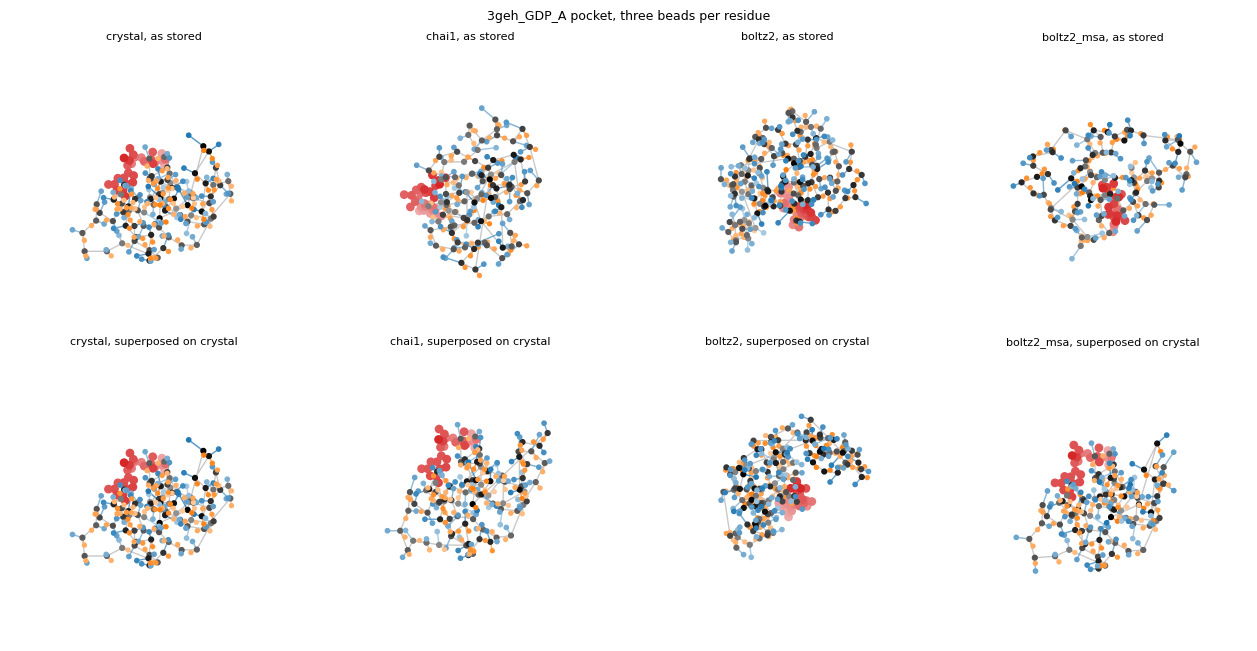

In [8]:
# cell 6 -- Top row as stored, bottom row after superposing each teacher's pocket
# onto the crystal one. The receptors share no frame, so the top row is not a
# comparison.
LW, LINK_LW, ALPHA = 0.98, 1.05, 0.75

def depth_fade(pts, ax, floor=0.4):
    e_, a_ = np.deg2rad(ax.elev), np.deg2rad(ax.azim)
    nrm = np.array([np.cos(e_)*np.cos(a_), np.cos(e_)*np.sin(a_), np.sin(e_)])
    d = pts @ nrm
    if np.ptp(d) < 1e-9: return np.ones(len(pts))
    return floor + (1-floor) * (d - d.min()) / np.ptp(d)

def fade(colour, w):
    c = np.array(plt.matplotlib.colors.to_rgb(colour))
    return np.clip(1 - np.outer(w, 1 - c), 0, 1)

def kabsch(P, Q):
    pc_, qc = P.mean(0), Q.mean(0)
    U, _, Vt = np.linalg.svd((P - pc_).T @ (Q - qc))
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    R = Vt.T @ np.diag([1, 1, d]) @ U.T
    return R, qc - R @ pc_

def draw(ax, ca, sc, pep, valid, lig, title, three=True):
    ax.view_init(elev=20, azim=-60)
    w = depth_fade(ca, ax)
    ax.plot(*ca.T, color="0.15", lw=LW, alpha=0.25, zorder=1)
    ax.scatter(*ca.T, s=12, c=fade("k", w), depthshade=False, zorder=2)
    if three:
        for A, B, v, wi in zip(ca, sc, valid, w):
            if v: ax.plot(*np.stack([A, B]).T, color=fade("tab:blue", [wi])[0],
                          lw=LINK_LW, alpha=ALPHA)
        ax.scatter(*sc[valid].T, s=9.5, c=fade("tab:blue", w[valid]), depthshade=False)
        for A, B, wi in zip(ca, pep, w):
            ax.plot(*np.stack([A, B]).T, color=fade("tab:orange", [wi])[0],
                    lw=LINK_LW, alpha=ALPHA)
        ax.scatter(*pep.T, s=8, c=fade("tab:orange", w), depthshade=False)
    ax.scatter(*lig.T, s=28, c=fade("tab:red", depth_fade(lig, ax)), depthshade=False, zorder=3)
    ax.set_title(title, fontsize=8)
    ax.set_axis_off()
    ax.set_box_aspect((1,1,1))

ref = beads(g, "crystal")
fig = plt.figure(figsize=(3.2*len(present), 6.6))
for j, t in enumerate(present):
    b = beads(g, t)
    axA = fig.add_subplot(2, len(present), j+1, projection="3d")
    draw(axA, *b, f"{t}, as stored")
    m = min(len(ref[0]), len(b[0]))
    R, tr = kabsch(b[0][:m], ref[0][:m])
    sup = tuple(x @ R.T + tr if isinstance(x, np.ndarray) and x.ndim == 2 and x.shape[1] == 3 else x
                for x in b)
    axB = fig.add_subplot(2, len(present), len(present)+j+1, projection="3d")
    draw(axB, *sup, f"{t}, superposed on crystal")
fig.suptitle(f"{sid} pocket, three beads per residue", fontsize=9)
plt.tight_layout()
plt.show()

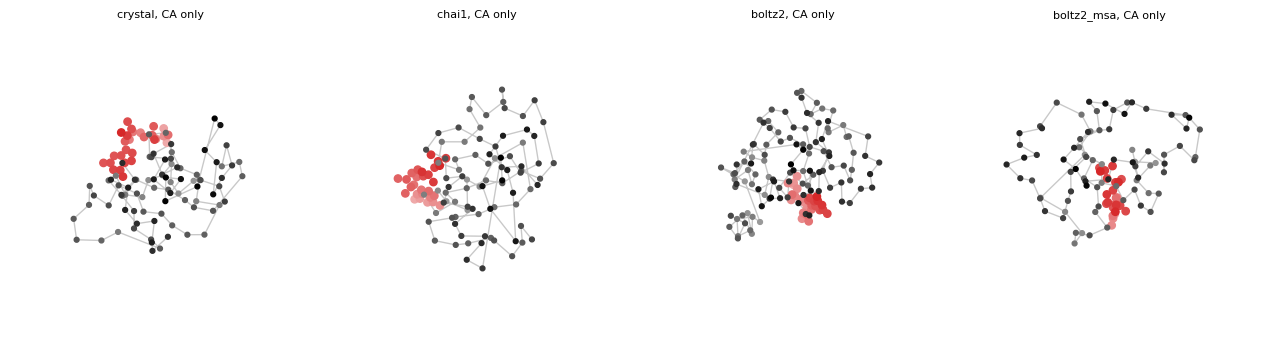

In [9]:
# cell 6b -- what a one-bead representation carries, for comparison
fig = plt.figure(figsize=(3.2*len(present), 3.4))
for j, t in enumerate(present):
    axA = fig.add_subplot(1, len(present), j+1, projection="3d")
    draw(axA, *beads(g, t), f"{t}, CA only", three=False)
plt.tight_layout()
plt.show()

In [10]:
!pip -q install py3Dmol
import py3Dmol

In [11]:
# cell 7 -- two pockets side by side, drag to rotate. Drawn as spheres and
# cylinders rather than as a molecule: the deposit stores points per residue, not
# atoms, and a cartoon would imply detail that is not there. 3Dmol fades distant
# geometry toward the background colour on its own.
def xyz(v): return {"x": float(v[0]), "y": float(v[1]), "z": float(v[2])}

def add_beads(view, ca, sc, pep, valid, lig, panel, links=True):
    for A, B, C, vd in zip(ca, sc, pep, valid):
        view.addSphere({"center": xyz(A), "radius": 0.49, "color": "black"}, viewer=panel)
        view.addSphere({"center": xyz(C), "radius": 0.42, "color": "orange"}, viewer=panel)
        if links:
            view.addCylinder({"start": xyz(A), "end": xyz(C), "radius": 0.15,
                              "color": "orange", "opacity": 0.6}, viewer=panel)
        if vd:
            view.addSphere({"center": xyz(B), "radius": 0.42, "color": "blue"}, viewer=panel)
            if links:
                view.addCylinder({"start": xyz(A), "end": xyz(B), "radius": 0.15,
                                  "color": "blue", "opacity": 0.6}, viewer=panel)
    for L in lig:
        view.addSphere({"center": xyz(L), "radius": 0.63, "color": "red"}, viewer=panel)

pair = present[:2]
v = py3Dmol.view(width=940, height=470, viewergrid=(1, 2))
v.setBackgroundColor("white")
for j, t in enumerate(pair):
    add_beads(v, *beads(g, t), (0, j))
v.zoomTo()
v.show()
print("left:", pair[0], "   right:", pair[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

left: crystal    right: chai1


In [12]:
# cell 8 -- Whole receptor rather than the pocket. STRIDE thins the residues
# if the viewer drags.
STRIDE = 1
which = pair[0]

ca_f, sc_f, pep_f, val_f, lig_f = beads(g, which, pocket_only=False)
v = py3Dmol.view(width=940, height=560)
v.setBackgroundColor("white")
add_beads(v, ca_f[::STRIDE], sc_f[::STRIDE], pep_f[::STRIDE], val_f[::STRIDE],
          lig_f, None, links=True)
v.zoomTo()
v.show()
print(f"{sid}, {which} receptor, {len(ca_f)} residues, ligand in red")
print("89 systems clip the int16 range at 327.67 A from the centroid, all in the "
      "full-protein arrays and none in the shell, ids in metadata/int16_saturated_systems.json")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3geh_GDP_A, crystal receptor, 442 residues, ligand in red
89 systems clip the int16 range at 327.67 A from the centroid, all in the full-protein arrays and none in the shell, ids in metadata/int16_saturated_systems.json
